## Building with LangGraph


### Building a Chatbot

In [1]:
from langgraph.graph import StateGraph # State management
from typing import Annotated # Validation
from typing_extensions import TypedDict # Validation
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

In [2]:
# Loading the API key from .env
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [3]:
# 1. Create the State object
class State(TypedDict):
    messages: Annotated[list, add_messages] 
    # add_message is an internal function which will append all the messages that are being send to the node.
    # messages is an Annotated list which keeps on growing.

# 2. Create a StateGraph
graph_builder = StateGraph(State)

# 3. Initialise the LLM
llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)

# 4. Define the Node
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

graph = graph_builder.compile()

### Visualizins the Graph

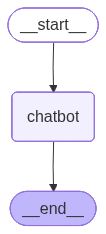

In [4]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# pip install -q grandalf

In [6]:
print(graph.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


### Running the ChatBot

In [7]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye', 'q']:
        print('Goodbye!')
        break

    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print(f"Assistant: {value["messages"][-1].content}")
            print('-' * 20)

User:  Paris is ...


Assistant: Paris is the capital city of France, known for its rich history, stunning architecture, and vibrant culture. It's often referred to as "The City of Light" (La Ville Lumière) due to its historical significance as a center of education and ideas during the Age of Enlightenment. 

Famous landmarks include the Eiffel Tower, the Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées. Paris is also renowned for its art, fashion, gastronomy, and romantic ambiance, making it a popular destination for tourists from around the world. The city is divided into 20 districts, or "arrondissements," each with its own unique character and attractions. 

In addition to its historical and cultural significance, Paris is a hub for international business and diplomacy, hosting numerous organizations and events. The city's influence on art, literature, and philosophy has left a lasting legacy that continues to inspire people globally.
--------------------


User:  Distance to moon in km


Assistant: The average distance from the Earth to the Moon is about 384,400 kilometers (approximately 238,855 miles). This distance can vary slightly due to the Moon's elliptical orbit around the Earth.
--------------------


User:  quit


Goodbye!


In [1]:
pip install -q tavily-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [3]:
from tavily import TavilyClient
import os

# Initializing a Tavily client
client = TavilyClient()

response = client.search(query="What is the bitcoin price today?")
response

{'query': 'What is the bitcoin price today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://coinmarketcap.com/currencies/bitcoin/',
   'title': 'Bitcoin price today, BTC to USD live price, marketcap and chart',
   'content': 'The live Bitcoin price today is $74503.63 USD with a 24-hour trading volume of $50930940537.99 USD. We update our BTC to USD price in real-time.',
   'score': 0.9998785,
   'raw_content': None},
  {'url': 'https://www.coindesk.com/price/bitcoin',
   'title': 'Bitcoin price today, BTC to USD live price, marketcap and chart',
   'content': 'The price of Bitcoin (BTC) is $74037.19 today as of Mar 17, 2026, 7:43 pm EDT, with a 24-hour trading volume of $26.41B.',
   'score': 0.9997131,
   'raw_content': None},
  {'url': 'https://www.coingecko.com/en/coins/bitcoin',
   'title': 'Bitcoin Price: BTC Live Price Chart, Market Cap & News Today',
   'content': 'The price of Bitcoin (BTC) is $74,715.82 today with a 24-hour trading

In [5]:
# Passing Tavily Results to an LLM using langchain
from langchain_community.adapters.openai import convert_openai_messages
from langchain_openai import ChatOpenAI

query = 'What is the "Reflection & Critique" pattern used in agentic applications and LangGraph?'

response = client.search(query, max_results=5, search_depth='advanced')['results']
response

[{'url': 'https://www.tungstenautomation.fr/learn/blog/the-agentic-ai-reflection-pattern',
  'title': 'The Agentic AI Reflection Pattern',
  'content': '# The Agentic AI Reflection Pattern\n\nFebruary 19, 2026\n\nThe Agentic AI Reflection Pattern is all about giving an AI system the ability to think about its own thinking. Instead of trusting the first response it produces, the system pauses, reviews what it just generated, evaluates whether it makes sense, and then improves it before delivering the final answer.\n\nThe Agentic AI Reflection Pattern\n\nYou can think of it as the AI doing an internal “quality check” on its own output, either by using external tools, external validators or its own reasoning loop with LLM as a critique. The AI effectively asks itself questions like:\n\n Did my answer follow the instructions correctly?\n Are there any gaps or contradictions?\n Can I make this clearer, safer, more accurate, or more aligned with the goal? [...] it generates a piece of text,\

In [6]:
prompt = [
    {
        'role': 'system',
        'content': f'''You are an AI critical thinker research assistant.
        Your sole purpose is to write well written, objective and structured reports on given text.'''
    },
    {
        'role': 'user',
        'content': f'''Information: """{response}"""
        Using the above informtion, answer the following query: """{query}""" in a detailed report'''
    }
]


lc_messages = convert_openai_messages(prompt)
lc_messages

[SystemMessage(content='You are an AI critical thinker research assistant.\n        Your sole purpose is to write well written, objective and structured reports on given text.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Information: """[{\'url\': \'https://www.tungstenautomation.fr/learn/blog/the-agentic-ai-reflection-pattern\', \'title\': \'The Agentic AI Reflection Pattern\', \'content\': \'# The Agentic AI Reflection Pattern\\n\\nFebruary 19, 2026\\n\\nThe Agentic AI Reflection Pattern is all about giving an AI system the ability to think about its own thinking. Instead of trusting the first response it produces, the system pauses, reviews what it just generated, evaluates whether it makes sense, and then improves it before delivering the final answer.\\n\\nThe Agentic AI Reflection Pattern\\n\\nYou can think of it as the AI doing an internal “quality check” on its own output, either by using external tools, external validators or its own reasoning loop wit

In [8]:
llm = ChatOpenAI(model='gpt-4o-mini')
response = llm.invoke(lc_messages)
print(response.content)

## Report on the "Reflection & Critique" Pattern in Agentic Applications and LangGraph

### Introduction
The "Reflection & Critique" pattern, frequently discussed in the context of agentic AI applications, represents a transformative approach for enhancing the cognitive capabilities of AI systems. Primarily, this pattern allows AI agents to introspect on their outputs, critique their own reasoning, and iteratively improve their responses. This report explores the foundational concepts, processes, advantages, and practical applications of the Reflection & Critique pattern, particularly as it pertains to systems like LangGraph.

### Definition of the Reflection & Critique Pattern
The Reflection & Critique pattern involves a cyclic process where an AI agent performs the following steps:

1. **Generation**: The agent creates an initial response to a given prompt or query.
2. **Reflection**: Post-generation, the agent enters a self-evaluation phase, assessing the quality and accuracy of its

### Adding Tools to the Chatbot

In [9]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults
tool = TavilySearchResults(max_results=3)
tools = [tool]

In [15]:
response = tool.invoke("What is gpt o1")
response

[{'title': 'o1: Smarter than we think (2024) – Dr Alan D. Thompson',
  'url': 'https://lifearchitect.ai/o1/',
  'content': 'C2. If GPT-4o is 200B Dense, then o1 could also be 200B Dense, but with significantly increased inference-time compute; equivalent to the performance of a 14T MoE model (equivalent to the performance of a model about 8× larger than GPT-4 Classic 1.76T).\n\nC2.1. In plain-ish English, o1 may be a 200B parameter model spending 4× thinking/reasoning before responding, and performing at the level of a 2.8T parameter model or 14T MoE model. [...] Observations\n\nObservation 1. Like GPT-4o (omni), o1 is multimodal: ‘Multimodal capabilities are built into o1, aiming for state-of-the-art performance in tasks like MMMU’ (OpenAI dev Q&A).\n\nObservation 2. o1 significantly outperforms GPT-4 Classic 1.76T MoE and GPT-4o across benchmarks. See Smarts.\n\nObservation 3. GPT-4o and o1 share a training data cutoff date. gpt-4o (2024-05-13) = Oct/2023. o1 = Oct/2023.\n\nObservati

In [21]:
# Chatbot Langgraph Code
from langgraph.graph import StateGraph # State management
from typing import Annotated # Validation
from typing_extensions import TypedDict # Validation
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

from langgraph.prebuilt import ToolNode, tools_condition
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
llm_tools = llm.bind_tools(tools)

# Define the Node
def chatbot(state: State):
    return {"messages": [llm_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
### NEW CODE
tool_node = ToolNode(tools=tools)
graph_builder.add_node('tools', tool_node)
# Adding condition edge between tool node and the node
graph_builder.add_conditional_edges(
    'chatbot',
    tools_condition
)

graph_builder.add_edge('tools', 'chatbot')

graph_builder.set_entry_point('chatbot')
# graph_builder.set_finish_point('chatbot')

graph = graph_builder.compile()

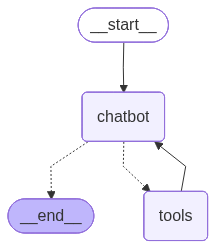

In [22]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye', 'q']:
        print('GoodBye!')
        break

    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print('Assistant: ', value['messages'][-1])

        print('-' * 50)

User:  Who won the swimming gold medal at Paris olympics?


Assistant:  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 90, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_85bc8ad402', 'id': 'chatcmpl-DKbF0FAxUFzIpD1JSDI18cqOoLQ6d', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cfed7-dd0a-7153-aada-a5b01a279576-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'swimming gold medal winner Paris Olympics 2024'}, 'id': 'call_khbW88oZm4pG9SYnDyqDmn4f', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 90, 'output_tokens': 27, 'total_tokens': 117, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

User:  What about Gymnastics?


Assistant:  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 85, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_85bc8ad402', 'id': 'chatcmpl-DKbFEJtO2yKHsS2MF7wbNgafBiz2l', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cfed8-1558-7e70-94fc-9020d7d23655-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Gymnastics news and updates'}, 'id': 'call_ntBKUNqgJ6Hm0Kgs6cGGC2H8', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 85, 'output_tokens': 23, 'total_tokens': 108, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 

User:  quit


GoodBye!
